# День 08. Упражнение 01
# Бинарный классификатор. SVM. Дерево решений

## 0. Импорты

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import numpy as np
am_pm = '../ex00/data/am_pm.csv'

## 1. Предобработка и визуализация логистической регрессии

In [2]:
df = pd.read_csv(am_pm)
df

,date,am,pm,target,predict
0,2020-04-17,21,2,working_day,1
1,2020-04-18,1,68,weekend,0
2,2020-04-19,18,15,weekend,0
3,2020-04-20,2,23,working_day,0
4,2020-04-21,0,25,working_day,0
5,2020-04-22,0,28,working_day,0
6,2020-04-23,10,33,working_day,0
7,2020-04-24,2,14,working_day,0
8,2020-04-25,30,74,weekend,0
9,2020-04-26,28,233,weekend,0


Прочитай файл am_pm.csv в DataFrame из предыдущего упражнения.
1. Построй график, где по оси x — am, по оси y — pm, точки — это дни, цвет зависит от целевой переменной.
2. Добавь на график границу решений логистической регрессии.
3. Построй тот же график (с границей), но на этот раз цвет должен зависеть от предсказаний.

Теперь тебе должно быть понятно, как работает логистическая регрессия.


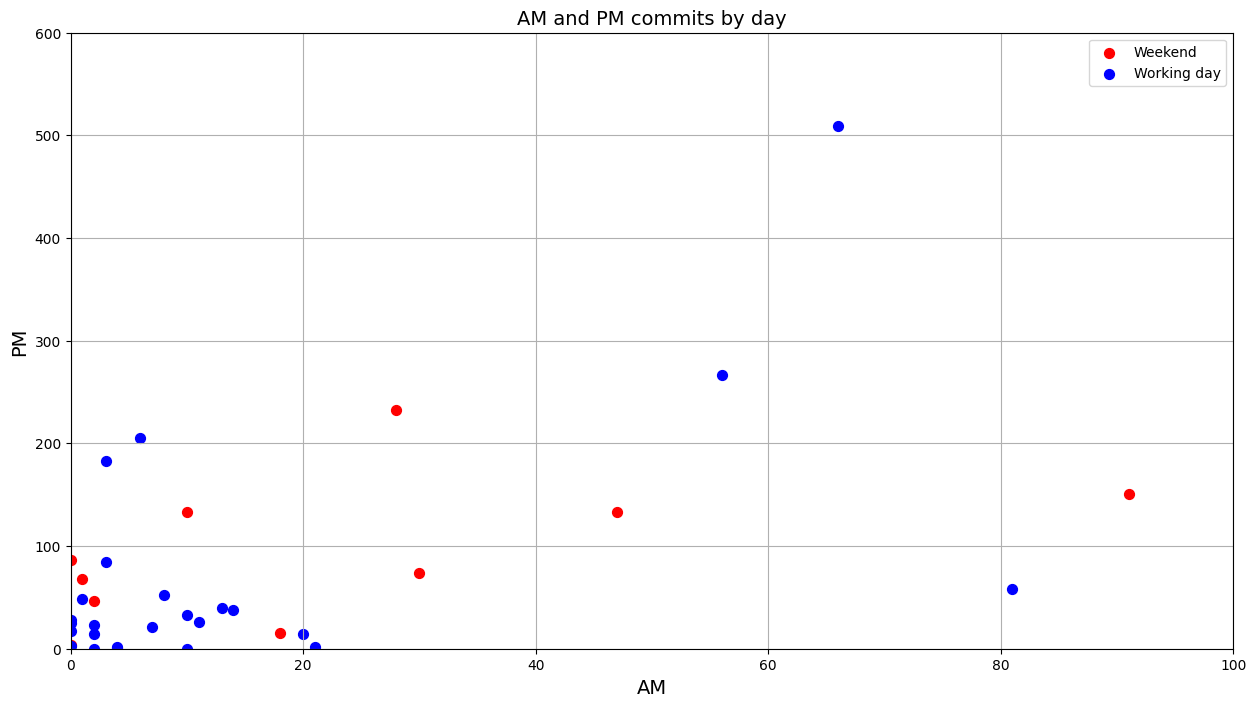

In [3]:
weekend = df[df['target'] == 'weekend']
working = df[df['target'] == 'working_day']

plt.figure(figsize=(15, 8))

plt.scatter(weekend['am'], weekend['pm'], 
            color='red', label='Weekend', alpha=1, s=50)
plt.scatter(working['am'], working['pm'], 
            color='blue', label='Working day', alpha=1, s=50)

plt.xlabel('AM', fontsize=14)
plt.ylabel('PM', fontsize=14)
plt.title('AM and PM commits by day', fontsize=14)
plt.ylim(0,600)
plt.xlim(-0,100)
plt.legend()
plt.grid(True)

plt.show()

In [4]:
x = df[['am', 'pm']]
y = (df['target'] == 'weekend').astype(int)

In [5]:
model = LogisticRegression(random_state=21, fit_intercept=False)
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",21
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solv

In [6]:
w1 = model.coef_[0][0]
w2 = model.coef_[0][1]

In [7]:
decision_boundary = (-1*w1*x)/w2


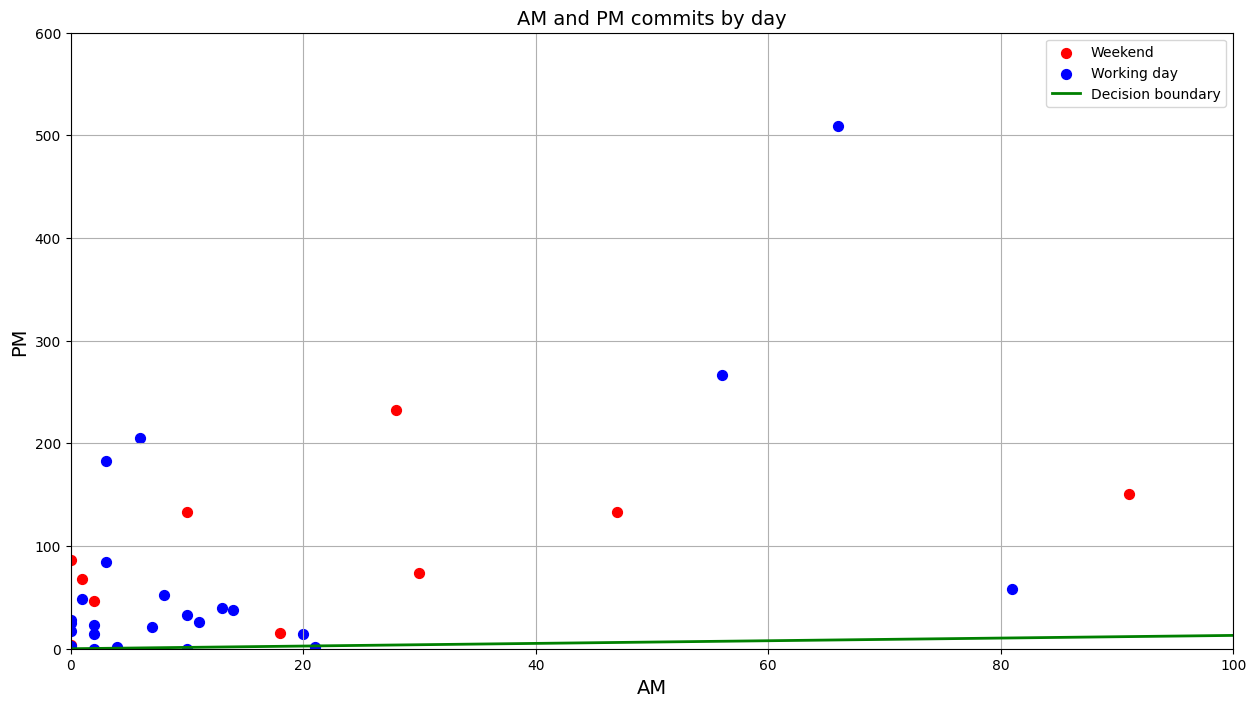

In [8]:
weekend = df[df['target'] == 'weekend']
working = df[df['target'] == 'working_day']

plt.figure(figsize=(15, 8))

plt.scatter(weekend['am'], weekend['pm'], 
            color='red', label='Weekend', alpha=1, s=50)
plt.scatter(working['am'], working['pm'], 
            color='blue', label='Working day', alpha=1, s=50)

x_line = np.array([0, 100])
y_line = (-w1 * x_line) / w2

plt.plot(x_line, y_line, color='green', linewidth=2, label='Decision boundary')

plt.xlabel('AM', fontsize=14)
plt.ylabel('PM', fontsize=14)
plt.title('AM and PM commits by day', fontsize=14)
plt.ylim(0,600)
plt.xlim(-0,100)
plt.legend()
plt.grid(True)

plt.show()

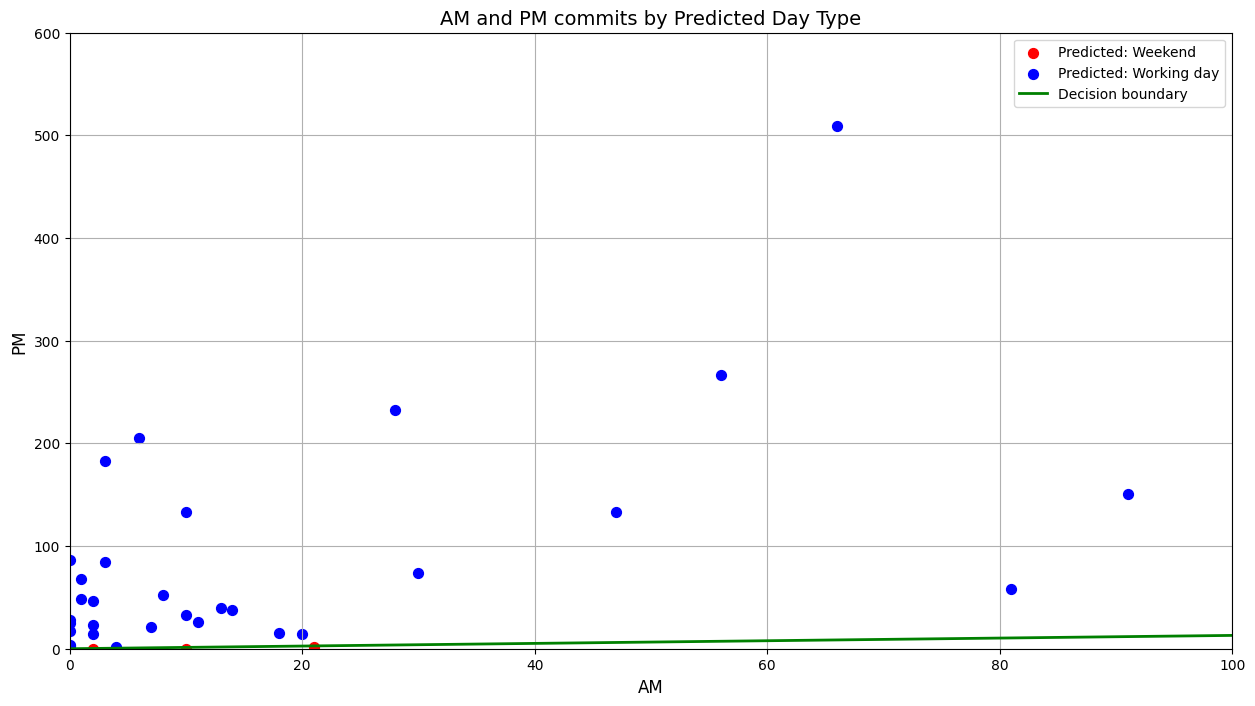

In [9]:
plt.figure(figsize=(15, 8))

pred_weekend = df[df['predict'] == 1]
pred_working = df[df['predict'] == 0]
x_line = np.array([0, 100])
y_line = (-w1 * x_line) / w2


plt.scatter(pred_weekend['am'], pred_weekend['pm'], 
            color='red', label='Predicted: Weekend', alpha=1, s=50)
plt.scatter(pred_working['am'], pred_working['pm'], 
            color='blue', label='Predicted: Working day', alpha=1, s=50)


plt.plot(x_line, y_line, color='green', linewidth=2, label='Decision boundary')
plt.xlabel('AM', fontsize=12)
plt.ylabel('PM', fontsize=12)
plt.ylim(0,600)
plt.xlim(-0,100)
plt.title('AM and PM commits by Predicted Day Type', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

## 2. Стандартизация и логистическая регрессия

Линейные модели чувствительны к масштабу переменных. Масштабирование признаков помогает модели проще находить оптимальное решение.

1. Применись StandardScaler к X и обучи логистическую регрессию снова с теми же параметрами.
2. Вычисли accuracy для новой модели. Стала ли она лучше наивного классификатора, предсказывающего самый частый класс?
3. Построй описанные выше графики, но уже для новой модели.

In [10]:
scaler = StandardScaler()

In [11]:
x_scaled = scaler.fit_transform(x)

In [12]:
model_scaled = LogisticRegression(random_state=21, fit_intercept=False)
model_scaled.fit(x_scaled, y)

,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",21
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solv

In [13]:
df_scaled = df.copy()
df_scaled['predict_scaled'] = model_scaled.predict(x_scaled) 

In [14]:
y_pred =  df_scaled['predict_scaled']
accuracy = accuracy_score(y, y_pred)
accuracy

0.7428571428571429

In [15]:
df_scaled

,date,am,pm,target,predict,predict_scaled
0,2020-04-17,21,2,working_day,1,0
1,2020-04-18,1,68,weekend,0,0
2,2020-04-19,18,15,weekend,0,0
3,2020-04-20,2,23,working_day,0,0
4,2020-04-21,0,25,working_day,0,0
5,2020-04-22,0,28,working_day,0,0
6,2020-04-23,10,33,working_day,0,0
7,2020-04-24,2,14,working_day,0,0
8,2020-04-25,30,74,weekend,0,1
9,2020-04-26,28,233,weekend,0,1


In [16]:
w1_scaled = model_scaled.coef_[0][0]
w2_scaled = model_scaled.coef_[0][1]
print(w1_scaled, w2_scaled)

0.2539279753302703 0.0738294714297179


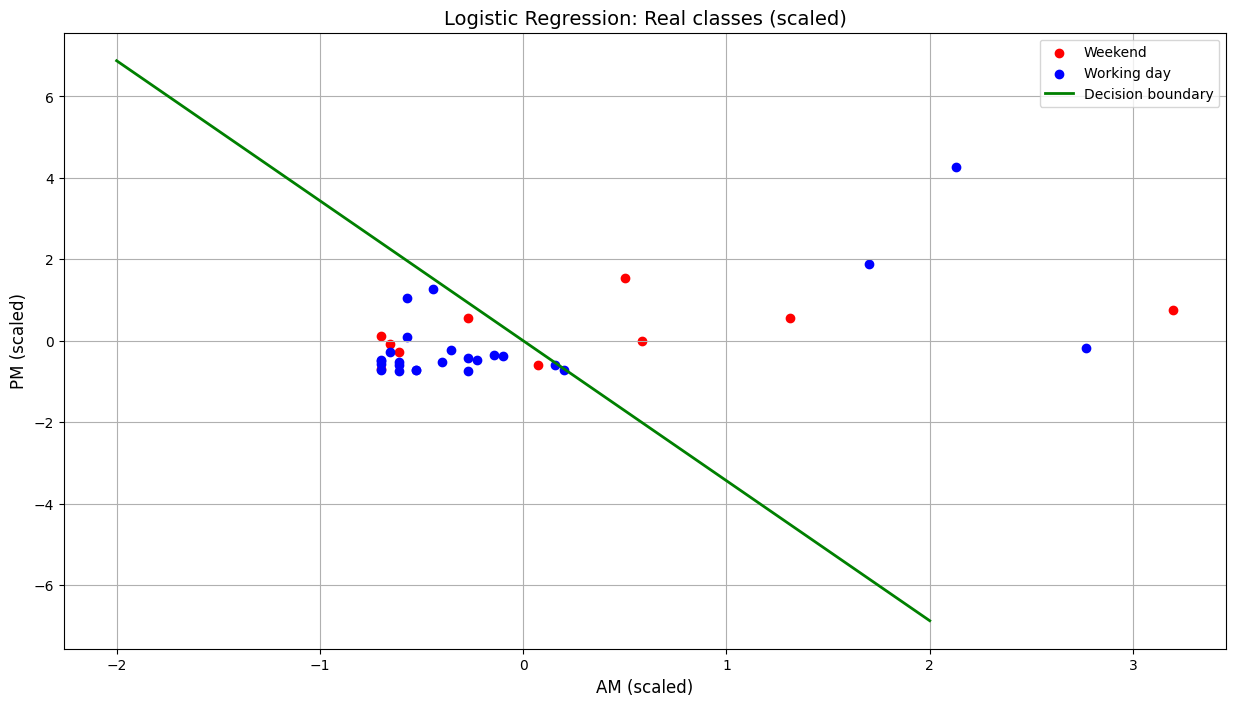

In [17]:
plt.figure(figsize=(15, 8))
plt.scatter(x_scaled[y==1][:, 0], x_scaled[y==1][:, 1], color='red', label='Weekend')
plt.scatter(x_scaled[y==0][:, 0], x_scaled[y==0][:, 1], color='blue', label='Working day')

x_line = np.array([-2, 2])
y_line = (-w1_scaled * x_line) / w2_scaled

plt.plot(x_line, y_line, color='green', linewidth=2, label='Decision boundary')
plt.xlabel('AM (scaled)', fontsize=12)
plt.ylabel('PM (scaled)', fontsize=12)
plt.title('Logistic Regression: Real classes (scaled)', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

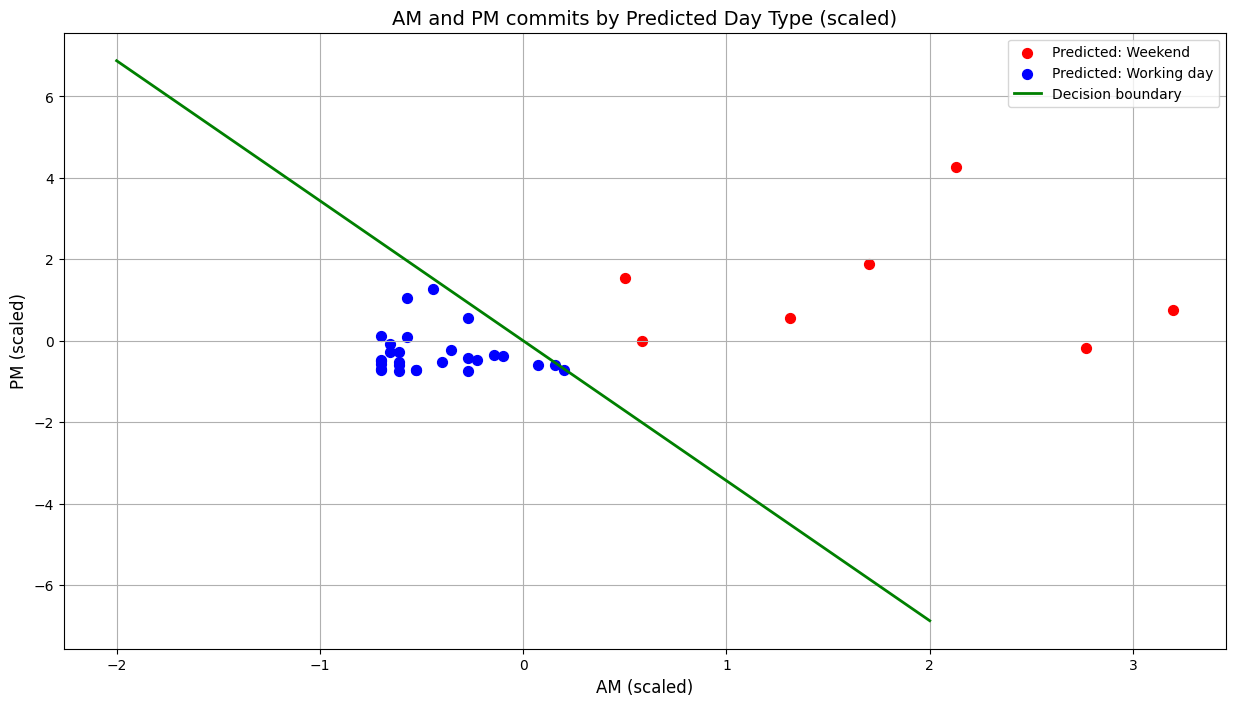

In [18]:
df_scaled_vis = df_scaled.copy()
df_scaled_vis[['am_scaled', 'pm_scaled']] = scaler.transform(df[['am', 'pm']])

plt.figure(figsize=(15, 8))

pred_weekend = df_scaled_vis[df_scaled_vis['predict_scaled'] == 1]
pred_working = df_scaled_vis[df_scaled_vis['predict_scaled'] == 0]

plt.scatter(pred_weekend['am_scaled'], pred_weekend['pm_scaled'], 
            color='red', label='Predicted: Weekend', alpha=1, s=50)
plt.scatter(pred_working['am_scaled'], pred_working['pm_scaled'], 
            color='blue', label='Predicted: Working day', alpha=1, s=50)

x_line = np.array([-2, 2])
y_line = (-w1_scaled * x_line) / w2_scaled

plt.plot(x_line, y_line, color='green', linewidth=2, label='Decision boundary')
plt.xlabel('AM (scaled)', fontsize=12)
plt.ylabel('PM (scaled)', fontsize=12)
plt.title('AM and PM commits by Predicted Day Type (scaled)', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

## 3. SVM

1. Применись модель SVC к масштабированному DataFrame с параметрами probability=True, random_state=21.
2. Вычисли accuracy.
3. Попробуй разные ядра и найди то, которое дает наилучшую точность.
4. Построй оба графика снова с границей решений, чтобы увидеть, как работает этот алгоритм.

In [19]:
model_svm = SVC(probability=True, random_state=21, kernel='rbf')

In [20]:
model_svm.fit(x_scaled, y)

/home/mnemokae/Desktop/School21_projects/DSB10_Intro_to_ML.ID_1577653-1/mnemokae/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",21
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [21]:
df_svm = df_scaled.copy()
df_svm['predict_svm'] = model_svm.predict(x_scaled) 

In [22]:
accuracy = accuracy_score(y,df_svm['predict_svm'])
accuracy

0.7428571428571429

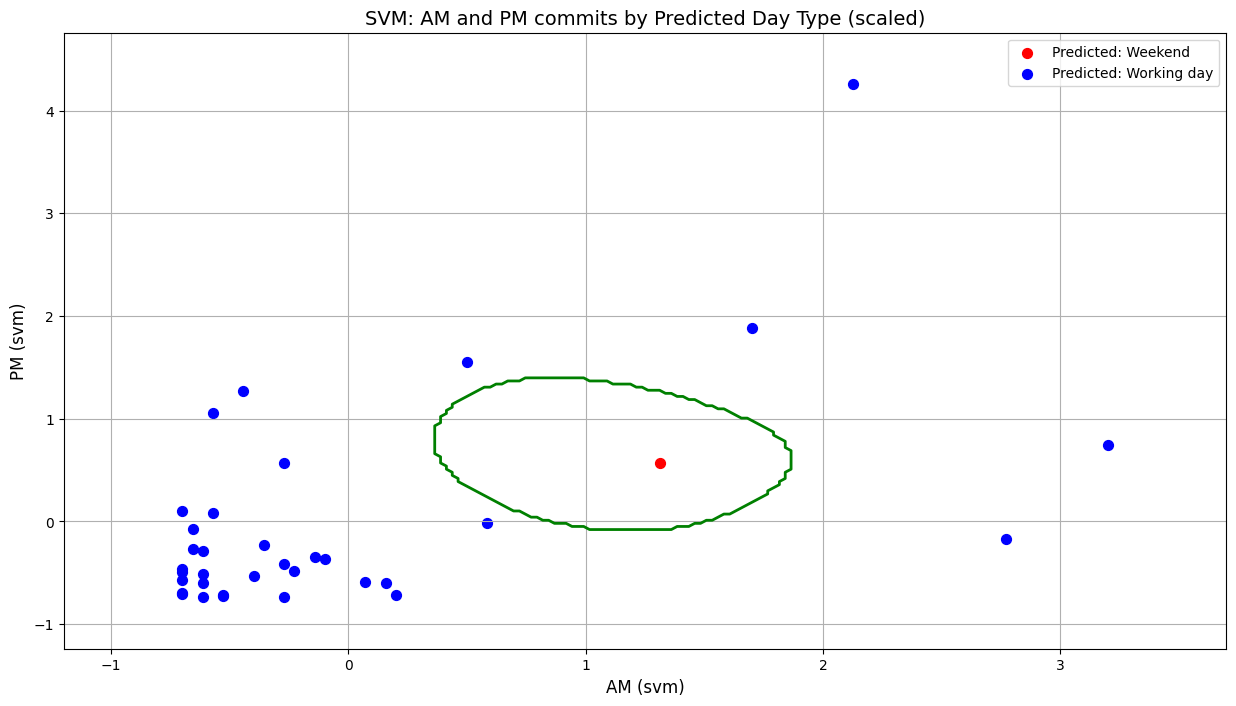

In [23]:
df_svm_vis = df_svm.copy()
df_svm_vis[['am_scaled', 'pm_scaled']] = scaler.transform(df[['am', 'pm']])

plt.figure(figsize=(15, 8))


pred_weekend = df_svm_vis[df_svm_vis['predict_svm'] == 1]
pred_working = df_svm_vis[df_svm_vis['predict_svm'] == 0]

plt.scatter(pred_weekend['am_scaled'], pred_weekend['pm_scaled'], 
            color='red', label='Predicted: Weekend', alpha=1, s=50)
plt.scatter(pred_working['am_scaled'], pred_working['pm_scaled'], 
            color='blue', label='Predicted: Working day', alpha=1, s=50)


x_min, x_max = df_svm_vis['am_scaled'].min() - 0.5, df_svm_vis['am_scaled'].max() + 0.5
y_min, y_max = df_svm_vis['pm_scaled'].min() - 0.5, df_svm_vis['pm_scaled'].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

Z = model_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.contour(xx, yy, Z, levels=[0.5], colors='green', linewidths=2)

plt.xlabel('AM (svm)', fontsize=12)
plt.ylabel('PM (svm)', fontsize=12)
plt.title('SVM: AM and PM commits by Predicted Day Type (scaled)', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

/home/mnemokae/Desktop/School21_projects/DSB10_Intro_to_ML.ID_1577653-1/mnemokae/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


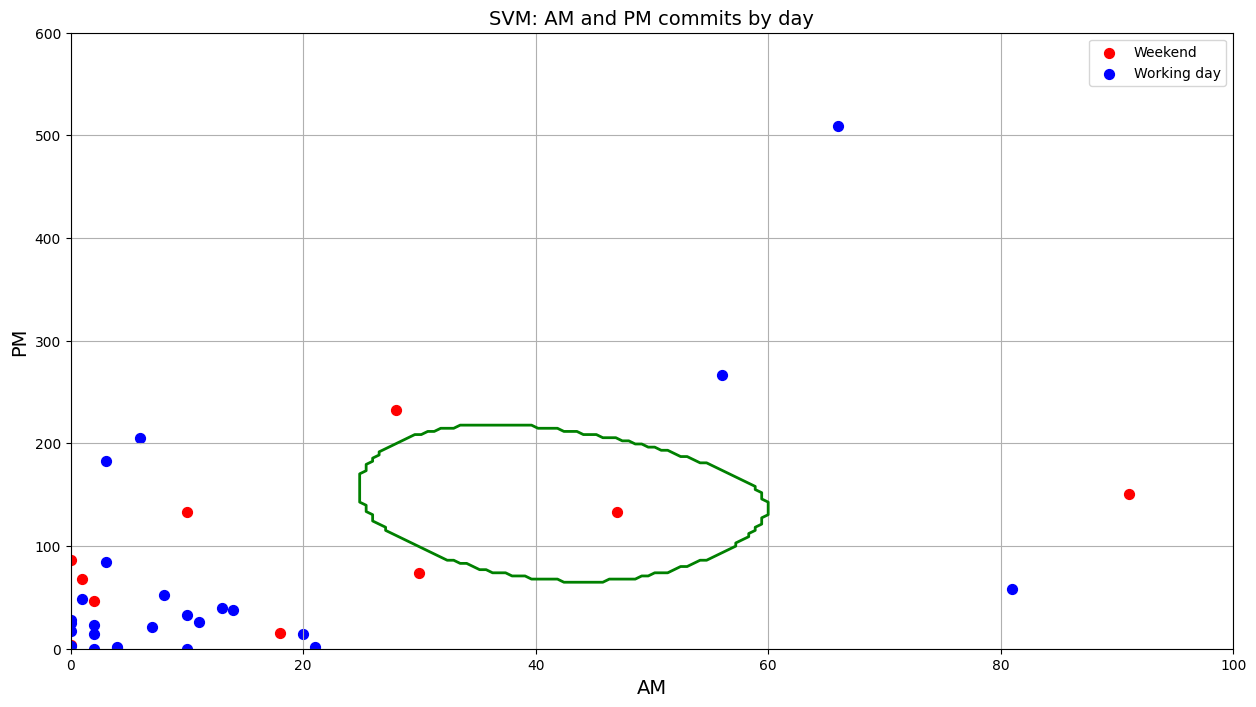

In [24]:

x_min, x_max = df['am'].min() - 10, df['am'].max() + 10
y_min, y_max = df['pm'].min() - 50, df['pm'].max() + 50
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))


grid_scaled = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
Z = model_svm.predict(grid_scaled)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(15, 8))
plt.scatter(weekend['am'], weekend['pm'], color='red', label='Weekend', alpha=1, s=50)
plt.scatter(working['am'], working['pm'], color='blue', label='Working day', alpha=1, s=50)

plt.contour(xx, yy, Z, levels=[0.5], colors='green', linewidths=2)

plt.xlabel('AM', fontsize=14)
plt.ylabel('PM', fontsize=14)
plt.title('SVM: AM and PM commits by day', fontsize=14)
plt.ylim(0,600)
plt.xlim(0,100)
plt.legend()
plt.grid(True)
plt.show()

## 4. Дерево решений

1. Применись DecisionTreeClassifier к масштабированному DataFrame с параметрами max_depth=4, random_state=42.
2. Вычисли accuracy.
3. Попробуй разные значения max_depth.
4. Построй оба графика снова с границей решений, чтобы увидеть, как работает этот алгоритм.
5. С помощью метода .plot_tree() визуализируй само дерево решений. Это еще один способ понять, как работает алгоритм.
6. Сколько листьев на визуализированном дереве обозначают рабочие дни? Напиши ответ в markdown-ячейке в конце раздела.

In [25]:
model_tree = DecisionTreeClassifier(max_depth=4, random_state=42)

In [26]:
model_tree.fit(x_scaled, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [27]:
df_tree = df_scaled.copy()
df_tree['predict_tree'] = model_tree.predict(x_scaled)

In [28]:
accuracy = accuracy_score(y,df_tree['predict_tree'])
accuracy

0.9428571428571428

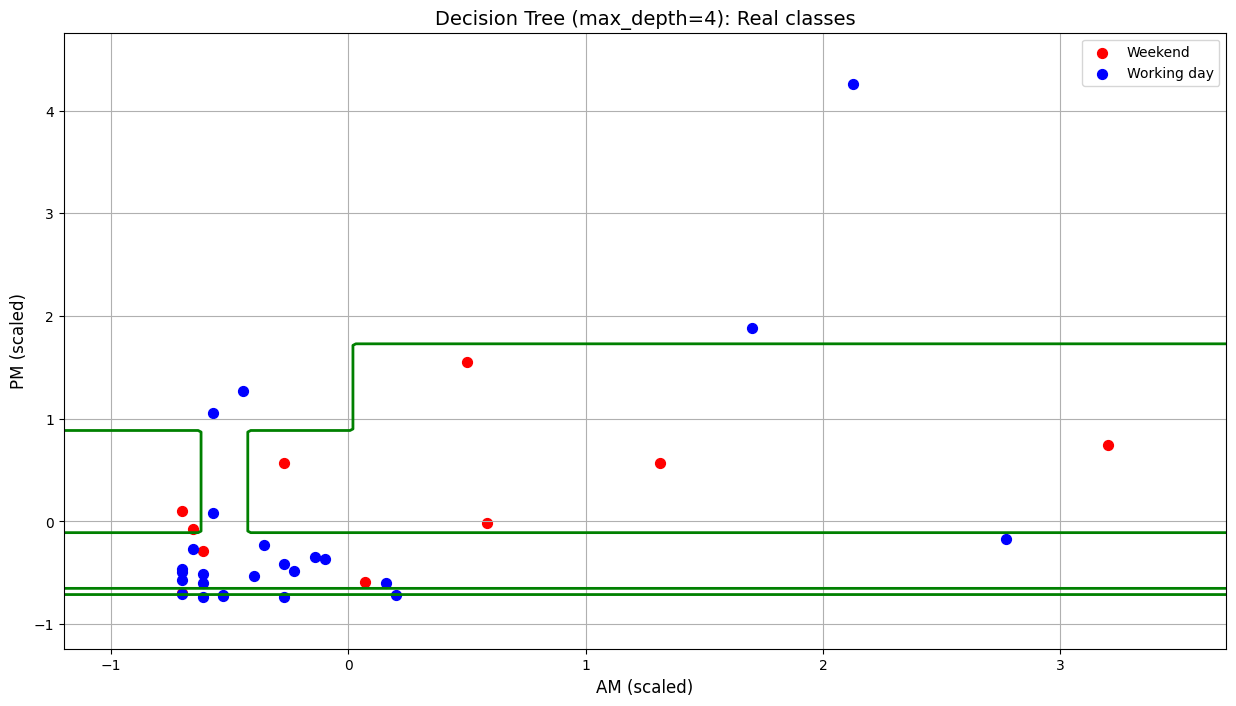

In [29]:
plt.figure(figsize=(15, 8))
plt.scatter(x_scaled[y==1][:, 0], x_scaled[y==1][:, 1], color='red', label='Weekend', s=50)
plt.scatter(x_scaled[y==0][:, 0], x_scaled[y==0][:, 1], color='blue', label='Working day', s=50)

x_min, x_max = x_scaled[:, 0].min() - 0.5, x_scaled[:, 0].max() + 0.5
y_min, y_max = x_scaled[:, 1].min() - 0.5, x_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

Z = model_tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0.5], colors='green', linewidths=2)

plt.xlabel('AM (scaled)', fontsize=12)
plt.ylabel('PM (scaled)', fontsize=12)
plt.title('Decision Tree (max_depth=4): Real classes', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

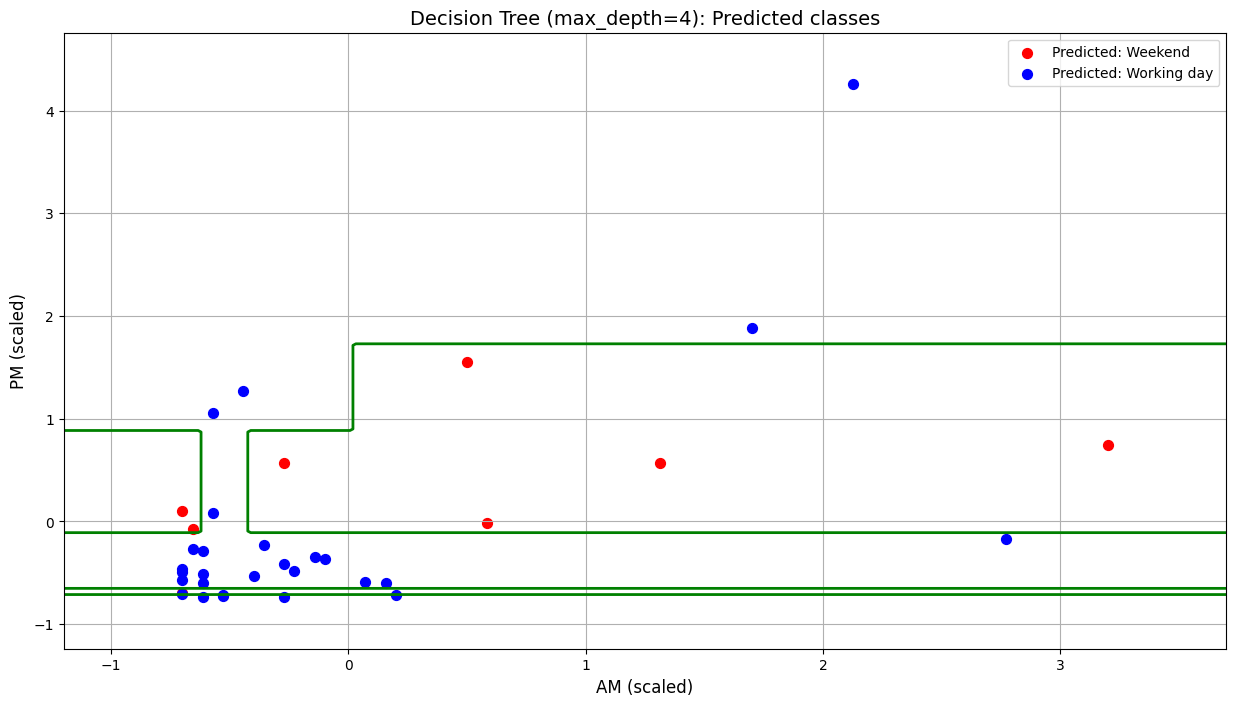

In [30]:
df_tree_vis = df_tree.copy()
df_tree_vis[['am_scaled', 'pm_scaled']] = scaler.transform(df[['am', 'pm']])

plt.figure(figsize=(15, 8))

pred_weekend = df_tree_vis[df_tree_vis['predict_tree'] == 1]
pred_working = df_tree_vis[df_tree_vis['predict_tree'] == 0]

plt.scatter(pred_weekend['am_scaled'], pred_weekend['pm_scaled'], 
            color='red', label='Predicted: Weekend', s=50)
plt.scatter(pred_working['am_scaled'], pred_working['pm_scaled'], 
            color='blue', label='Predicted: Working day', s=50)

Z = model_tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, levels=[0.5], colors='green', linewidths=2)

plt.xlabel('AM (scaled)', fontsize=12)
plt.ylabel('PM (scaled)', fontsize=12)
plt.title('Decision Tree (max_depth=4): Predicted classes', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

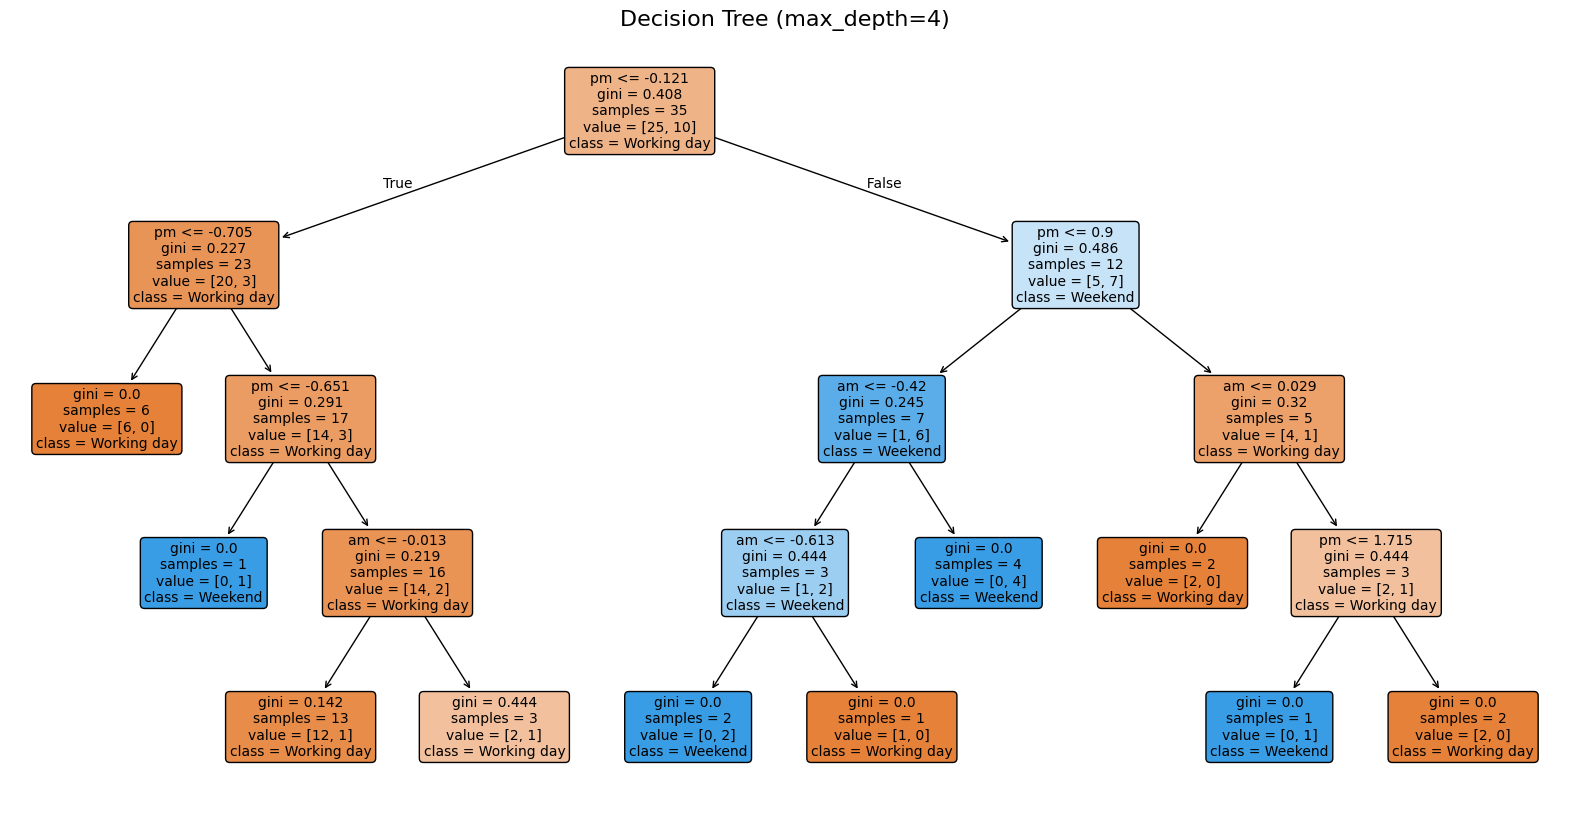

In [31]:
plt.figure(figsize=(20, 10))
plot_tree(model_tree, 
          feature_names=['am', 'pm'], 
          class_names=['Working day', 'Weekend'],
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Decision Tree (max_depth=4)', fontsize=16)
plt.show()

Ответ: 4 листа